### 🧠 Zadanie 20 – Kompletny projekt ML

Przeprowadź pełny projekt ML: od EDA po ewaluację.

**Wymagania:**
- EDA z wizualizacjami
- Feature engineering (nowe cechy)
- Porównanie 3+ modeli regresji
- Cross-validation
- Feature importance
- Raport końcowy z wnioskami
- Aspekt Green IT: porównanie efektywności

**Oczekiwany rezultat:** Notebook z pełnym projektem, wizualizacje EDA, tabela porównawcza, wnioski

*(challenge)*

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import time


In [20]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [21]:
print(X.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [22]:
X['MedInc_log'] = np.log1p(X['MedInc'])
X['HouseAge_log'] = np.log1p(X['HouseAge'])

X['RoomsPerHousehold'] = X['AveRooms'] / X['AveOccup']

X['BedroomRatio'] = X['AveBedrms'] / X['AveRooms']

X['IncomeHouseAge'] = X['MedInc'] * X['HouseAge']

print(f"Po feature engineering: {X.shape[1]} cech (zamiast {data.data.shape[1]})")

Po feature engineering: 13 cech (zamiast 8)


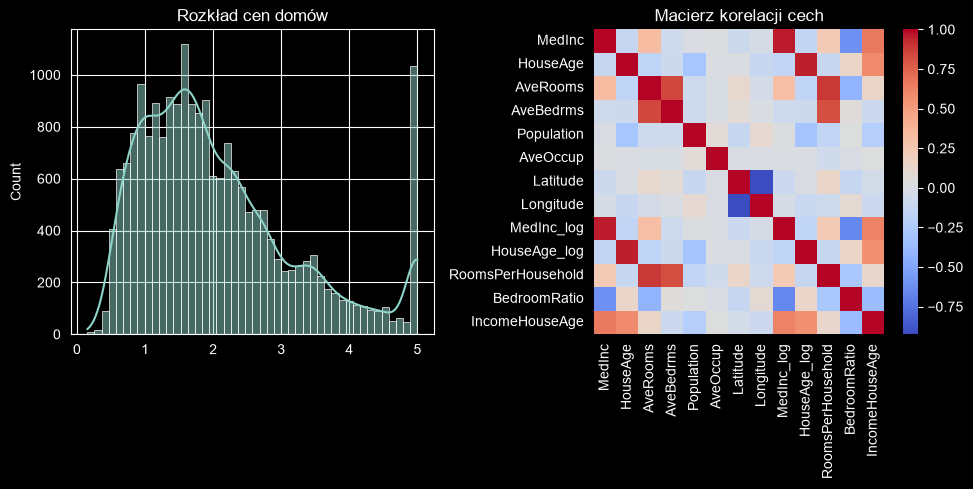

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(y, kde=True)
plt.title('Rozkład cen domów')

plt.subplot(1, 3, 2)
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech')


plt.tight_layout()
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [25]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    start_time = time.perf_counter()
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
    mean_cv_rmse = -np.mean(cv_scores)
    
    model.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - start_time

    y_pred = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = {
        'CV_RMSE': mean_cv_rmse,
        'Test_RMSE': test_rmse,
        'Train_Time_s': train_time
    }
    
    print(f"{name}: CV RMSE={mean_cv_rmse:.4f}, Test RMSE={test_rmse:.4f}, Czas: {train_time:.2f}s")


Linear Regression: CV RMSE=0.6793, Test RMSE=0.6749, Czas: 0.03s
Random Forest: CV RMSE=0.5168, Test RMSE=0.5091, Czas: 73.62s
Gradient Boosting: CV RMSE=0.5299, Test RMSE=0.5399, Czas: 27.22s


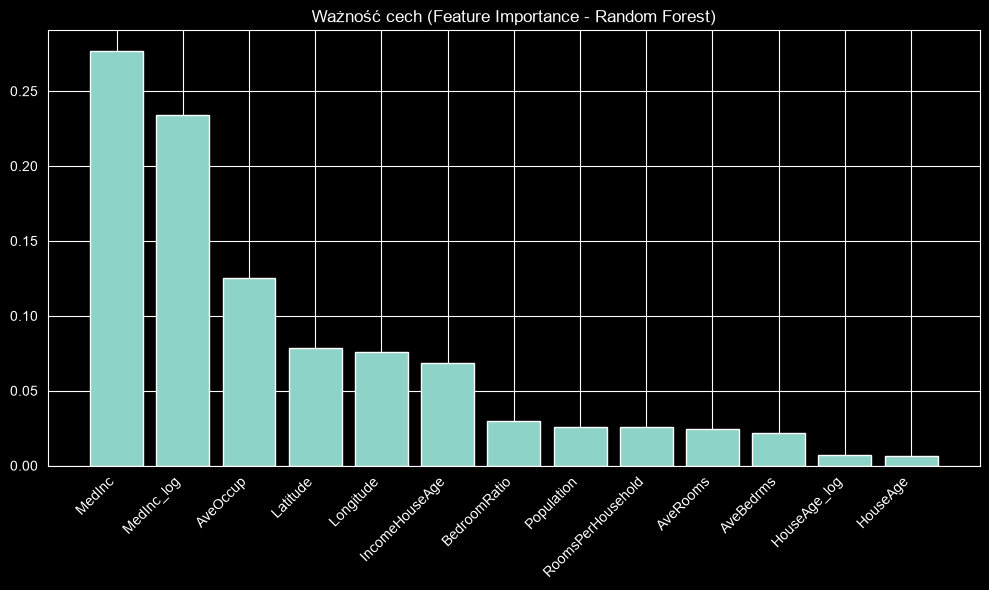

In [26]:
plt.figure(figsize=(10, 6))
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.title('Ważność cech (Feature Importance - Random Forest)')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
df_results = pd.DataFrame(results).T
print(df_results.round(4))

best_model_name = df_results['Test_RMSE'].idxmin()
greenest_model_name = df_results['Train_Time_s'].idxmin()

print(f"\nNajlepszy model (najniższy błąd): {best_model_name}")
print(f"Najszybszy trening: {greenest_model_name}")

top_feature = X.columns[indices[0]]
print(f"\nKluczowa cecha dla predykcji: '{top_feature}'")

                   CV_RMSE  Test_RMSE  Train_Time_s
Linear Regression   0.6793     0.6749        0.0308
Random Forest       0.5168     0.5091       73.6187
Gradient Boosting   0.5299     0.5399       27.2202

Najlepszy model (najniższy błąd): Random Forest
Najszybszy trening: Linear Regression

Kluczowa cecha dla predykcji: 'MedInc'
